# **Tutorial 1 SpatialEx Translates Histology to Omics at Single-Cell Resolution**

In [ ]:
pip install SpatialEx scanpy cellpose

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 150.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 141.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import SpatialEx as se

device = 'cuda:0'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Prepare the dataset

### Choice 1: [Download](https://www.10xgenomics.com/products/xenium-in-situ/human-breast-dataset-explorer) the Xenium Human Breast Cancer tissue dataset.

We provide H&E patch representations generated by different H&E foundation models in the following links, and the expression data is preprocessed:

**UNI (Default)**: [Slice 1](https://drive.google.com/file/d/1730OXeBG6TDQ6ejs5oRGKYhdNXbIU19i/view?usp=sharing) and [Slice 2](https://drive.google.com/file/d/17WhaKtG3iXuZuubIJEi4Y0_0z1TMKIRx/view?usp=sharing)


**CONCH**: [Slice 1](https://drive.google.com/file/d/1WmSN4EWkmj1VFKZZbwWl3oGZAa50NMRN/view?usp=drive_link) and [Slice 2](https://drive.google.com/file/d/1hrhxLl7gBVZykiqxjLc0Od9NAbzb_t_T/view?usp=drive_link)

**Gigapath**: [Slice 1](https://drive.google.com/file/d/1x-ZYl7Nda53_VXCqpHO0OloC5g2DPS0-/view?usp=drive_link) and [Slice 2](https://drive.google.com/file/d/16aypi0NFTDsYr6Yuh3vf1b7SbiqehX6c/view?usp=drive_link)

**Phikon**: [Slice 1](https://drive.google.com/file/d/1jiwdqXjQp240jN0F3XZhVW8JJZ1YQIoR/view?usp=drive_link) and [Slice 2](https://drive.google.com/file/d/1qF3XQR0C0PmYQnzeyKu68K7sngA_y2L-/view?usp=drive_link)

**ResNet50**: [Slice 1](https://drive.google.com/file/d/1aamspsRvPPcKIyApqieAspEqwFcvxgea/view?usp=drive_link) and [Slice 2](https://drive.google.com/file/d/1DwkotYbpeJKWlGFEM6enH2LC3Q4VVeRb/view?usp=drive_link)

In [4]:
image_encoder = 'UNI'

if image_encoder == 'CONCH':
    adata1 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep1/Human_Breast_Cancer_Rep1_conch_resolution64_full.h5ad')
    adata2 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep2/Human_Breast_Cancer_Rep2_conch_resolution64_full.h5ad')
elif image_encoder == 'Gigapath':
    adata1 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep1/Human_Breast_Cancer_Rep1_gigapath_resolution64_full.h5ad')
    adata2 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep2/Human_Breast_Cancer_Rep2_gigapath_resolution64_full.h5ad')
elif image_encoder == 'Phikon':
    adata1 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep1/Human_Breast_Cancer_Rep1_phikon_resolution64_full.h5ad')
    adata2 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep2/Human_Breast_Cancer_Rep2_phikon_resolution64_full.h5ad')
elif image_encoder == 'Resnet50':
    adata1 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep1/Human_Breast_Cancer_Rep1_resnet50_resolution64_full.h5ad')
    adata2 = sc.read_h5ad('./datasets/Human_Breast_Cancer_Rep2/Human_Breast_Cancer_Rep2_resnet50_resolution64_full.h5ad')
else:
    adata1 = sc.read_h5ad('/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep1_uni_resolution64_full.h5ad')
    adata2 = sc.read_h5ad('/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep2_uni_resolution64_full.h5ad')

In [ ]:
def Tiling_HE_patches_by_coor(resolution, coor, img, col_name=['col', 'row']):  # iStar中说，单细胞大小约为8um*8um

    print('======================== Tiling HE patches for each single cells ===========================')



    patch_radius = int(resolution / 2.0)

    outlier_cells1 = np.where(coor < patch_radius)[0]

    outlier_cells2 = np.where(coor[col_name[0]] > (img.shape[1] - patch_radius))[0]

    outlier_cells3 = np.where(coor[col_name[1]] > (img.shape[0] - patch_radius))[0]

    outlier_cells = np.unique(np.hstack([outlier_cells1, outlier_cells2, outlier_cells3]))

    if len(outlier_cells) != 0:

        print('Remove the outlier cells, and Anndata file was reduced!')

        inlier_cells = set(np.arange(coor.shape[0])) - set(outlier_cells)

        coor = coor.iloc[list(inlier_cells)]

    he_patches = [0] * coor.shape[0]

    for i in tqdm(range(coor.shape[0])):

        x, y = coor.iloc[i][col_name[0]], coor.iloc[i][col_name[1]]

        he_patches[i] = torch.tensor(img[y - patch_radius: y + patch_radius, x - patch_radius:x + patch_radius])

    return torch.stack(he_patches, dim=0) / 255.0, coor

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import SpatialEx as se

# 1. 准备"模具大小"
my_resolution = 64

# 2. 准备"定位图纸" (假设你有一个保存了坐标的CSV文件)
# 这个表格必须包含 'col' 和 'row' 这两列数字
my_coordinates = pd.read_csv('/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep1/HBRC_Rep1_cell_coor.csv')

# 3. 准备"面团"
# Use se.pp.Read_HE_image to read tif file instead of np.load
img_path = '/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif'
my_image, scale = se.pp.Read_HE_image(img_path)

# === 执行裁剪 ===
# 也就是执行你刚才发的那段代码
final_patches, safe_coordinates = Tiling_HE_patches_by_coor(
    resolution = my_resolution,
    coor = my_coordinates,
    img = my_image,
    col_name = ['image_col', 'image_row'] # Add col_name back since your df has these names
)


In [ ]:
import anndata as ad
import numpy as np

print("1. 正在创建用于存储外部区域细胞特征的 AnnData 对象...")
# 你的 adata1 是测序区域的细胞，而这里的 safe_coordinates 是非测序区域的细胞。
# 为了满足 SpatialEx API 的要求，我们用坐标数据为这些外部细胞初始化一个新的 AnnData。
out_adata = ad.AnnData(obs=safe_coordinates.copy())

print("2. 正在使用 UNI 模型提取细胞特征 (这可能需要几分钟时间)...")
# 调用模型提取特征
out_adata = se.pp.Extract_HE_patches_representaion(
    he_patches=final_patches,
    adata=out_adata,
    image_encoder='uni', # 使用 UNI 模型提取
    device=device,
    store_key='he',
    skip_embedding=True
)

# 提取出来的特征矩阵
extracted_features = out_adata.obsm['he']
print(f"\n特征提取完成，特征矩阵的形状为: {extracted_features.shape}")

# === 保存特征矩阵 ===
save_npy_path = '/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep1/HBRC_Rep1_Out_uni2.npy'
np.save(save_npy_path, extracted_features)
print(f"3. 特征已成功保存至: {save_npy_path}")


### Choice 2: Preprocess your own data from scratch.
```
datasets/
│
├── Human_Breast_Cancer_Rep1/                  # The 1st slice
│   ├── cell_feature_matrix.h5                    
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif          
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv
│   ├── HBRC_Rep1_cell_coor.csv               # Cell segmentation result on H&E image
│   ├── HBRC_Rep1_Out_uni.npy
│
├── Human_Breast_Cancer_Rep2/                  # The 2nd slice
│   ├── cell_feature_matrix.h5
│   ├── cells.csv
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif        
│   ├── Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv
│   ├── HBRC_Rep2_cell_coor.csv
│   ├── HBRC_Rep2_Out_uni.npy
```

### 1.1 Preprocess Slice 1

In [8]:
save_root1 = '/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep1/'
save_root2 = '/content/drive/MyDrive/cancer/Human_Breast_Cancer_Rep2/'
resolution = 64
image_encoder = 'uni'

In [ ]:
file_path1 = save_root1 + 'cell_feature_matrix.h5'
obs_path1 = save_root1 + 'cells.csv'
img_path1 = save_root1 + 'Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.ome.tif'
transform_mtx_path1 = save_root1 + 'Xenium_FFPE_Human_Breast_Cancer_Rep1_he_imagealignment.csv'
adata1 = se.pp.Read_Xenium(file_path1, obs_path1)
adata1 = se.pp.Preprocess_adata(adata1)

img, scale = se.pp.Read_HE_image(img_path1)
transform_mtx = pd.read_csv(transform_mtx_path1, header=None).values
adata1 = se.pp.Register_physical_to_pixel(adata1, transform_mtx, scale=scale)
he_patches, adata1 = se.pp.Tiling_HE_patches(resolution, adata1, img)
adata1 = se.pp.Extract_HE_patches_representaion(he_patches, adata=adata1, image_encoder=image_encoder, device=device, store_key='he',skip_embedding=True)

### 1.2 Preprocess Slice 2

In [ ]:
file_path2 = save_root2 + 'cell_feature_matrix.h5'
obs_path2 = save_root2 + 'cells.csv'
img_path2 = save_root2 + 'Xenium_FFPE_Human_Breast_Cancer_Rep2_he_image.ome.tif'
transform_mtx_path2 = save_root2 + 'Xenium_FFPE_Human_Breast_Cancer_Rep2_he_imagealignment.csv'
adata2 = se.pp.Read_Xenium(file_path2, obs_path2)
adata2 = se.pp.Preprocess_adata(adata2)

img, scale = se.pp.Read_HE_image(img_path2)
transform_mtx = pd.read_csv(transform_mtx_path2, header=None).values
adata2 = se.pp.Register_physical_to_pixel(adata2, transform_mtx, scale=scale)
he_patches, adata2 = se.pp.Tiling_HE_patches(resolution, adata2, img)
adata2 = se.pp.Extract_HE_patches_representaion(he_patches, adata=adata2, image_encoder=image_encoder, store_key='he', device=device, skip_embedding=True,)

## 2. Train SpatialEx

### 2.1 Within the squencing area

In [5]:
num_neighbors = 7
epochs = 500

graph1 = se.pp.Build_hypergraph_spatial_and_HE(adata1, num_neighbors, graph_kind='spatial', return_type='crs')
graph2 = se.pp.Build_hypergraph_spatial_and_HE(adata2, num_neighbors, graph_kind='spatial', return_type='crs')

spatialex = se.SpatialEx(adata1, adata2, graph1, graph2, epochs=epochs, device=device)
spatialex.train()
panelB1, panelA2 = spatialex.auto_inference()

164000  cells are included in its nearest spot!
111555  cells are included in its nearest spot!


=================================== Start training =========================================


#Epoch: 206: train_loss: 17.32:  41%|████▏     | 207/500 [02:12<03:07,  1.57it/s]


KeyboardInterrupt: 

### 2.2 Outside the squencing area

In [9]:
out_spatial1 = pd.read_csv(save_root1 + '/HBRC_Rep1_cell_coor.csv', index_col=0)
out_spatial2 = pd.read_csv(save_root2 + '/HBRC_Rep2_cell_coor.csv', index_col=0)
out_he1 = np.load(save_root1 + '/HBRC_Rep1_Out_uni.npy')
out_he2 = np.load(save_root2 + '/HBRC_Rep2_Out_uni.npy')

graph1 = se.pp.Build_hypergraph(out_spatial1.values, num_neighbors=num_neighbors, normalize=True)
graph2 = se.pp.Build_hypergraph(out_spatial2.values, num_neighbors=num_neighbors, normalize=True)

panelA1_out = spatialex.inference(out_he1, graph1, panel='panelA')
panelA2_out = spatialex.inference(out_he2, graph2, panel='panelA')
panelB1_out = spatialex.inference(out_he1, graph1, panel='panelB')
panelB2_out = spatialex.inference(out_he2, graph2, panel='panelB')

RuntimeError: addmm: Argument #3 (dense): Expected dim 0 size 168614, got 836616

## 3. Evalulation

### 3.1 Quantatitive metrics

#### 3.1.1 Training on Slice 1, test on Slice 2

In [11]:
graph = se.pp.Build_graph(adata1.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')
ssim, ssim_reduce = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='ssim', graph=graph, reduce='mean')
pcc, pcc_reduce = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='pcc', reduce='mean')
cmd, cmd_reduce = se.utils.Compute_metrics(adata1.X.copy(), panelB1.copy(), metric='cmd', reduce='mean')
print('Evaluation of the predicted gene expression on Slice 2, PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

x shape is  164000
cell number is less than 200000
Evaluation of the predicted gene expression on Slice 2, PCC:  0.25404942  SSIM:  0.3644748838761616  CMD:  0.19686067


#### 3.1.2 Training on Slice 2, test on Slice 1

In [12]:
graph = se.pp.Build_graph(adata2.obsm['spatial'], graph_type='knn', weighted='gaussian', apply_normalize='row', return_type='coo')
ssim, ssim_reduce = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='ssim', graph=graph)
pcc, pcc_reduce = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='pcc', reduce='mean')
cmd, cmd_reduce = se.utils.Compute_metrics(adata2.X.copy(), panelA2.copy(), metric='cmd', reduce='mean')
print('Evaluation of the predicted gene expression on Slice 1, PCC: ', pcc_reduce, ' SSIM: ', ssim_reduce, ' CMD: ', cmd_reduce)

x shape is  111555
cell number is less than 200000
Evaluation of the predicted gene expression on Slice 1, PCC:  0.2743646  SSIM:  0.38087805832391747  CMD:  0.20757347


### 3.2 Visualization

#### 3.2.1 Training on Slice 1, test on Slice 2

In [13]:
col_min, col_max = adata2.obsm['image_coor'][:, 1].min(), adata2.obsm['image_coor'][:, 1].max()
row_min, row_max = adata2.obsm['image_coor'][:, 0].min(), adata2.obsm['image_coor'][:, 0].max()
selection = (out_spatial2['image_row'] > row_min) & (out_spatial2['image_row'] < row_max) & (out_spatial2['image_col'] > col_min) & (out_spatial2['image_col'] < col_max)
obs_inner = out_spatial2[selection]
var_names = adata1.var_names

NameError: name 'panelA2_out' is not defined

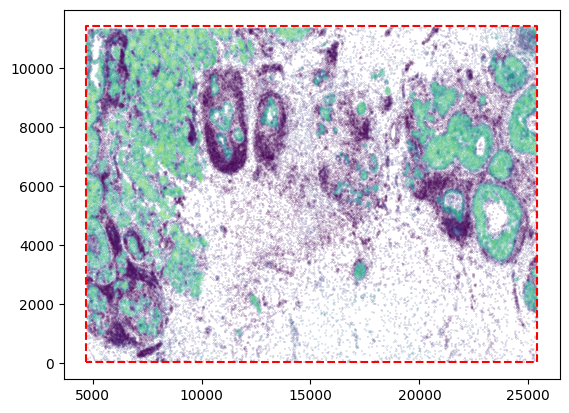

In [14]:
gene_name = 'EPCAM'
gene_idx = np.where(adata1.var_names == gene_name)[0]

value = panelA2[:, gene_idx]
vmax = value.max()
x, y = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmax=vmax, s=0.01)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

value = panelA2_out[:, gene_idx]
x, y = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection], x[~selection], c=value[~selection], s=0.01, vmin=0, vmax=vmax)

plt.title(gene_name)
plt.ylim((0,x.max()))
plt.xlim((0,y.max()))
plt.axis('off')
ax = plt.gca()
ax.set_aspect(1)
plt.show()

NameError: name 'panelA2_out' is not defined

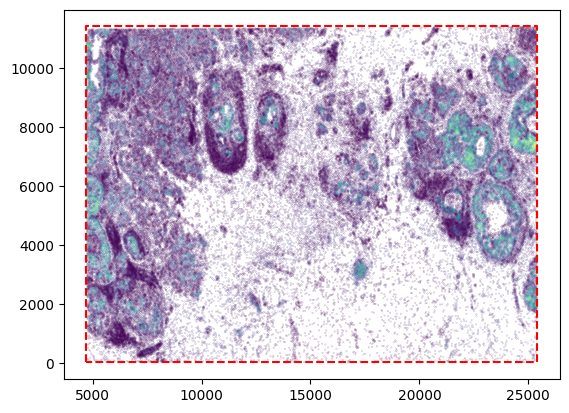

In [15]:
gene_name = 'ESR1'
gene_idx = np.where(adata1.var_names == gene_name)[0]

value = panelA2[:, gene_idx]
vmax = value.max()
x, y = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmax=vmax, s=0.01)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

value = panelA2_out[:, gene_idx]
x, y = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection], x[~selection], c=value[~selection], s=0.01, vmin=0, vmax=vmax)

plt.title(gene_name)
plt.ylim((0,x.max()))
plt.xlim((0,y.max()))
plt.axis('off')
ax = plt.gca()
ax.set_aspect(1)
plt.show()

In [ ]:
gene_name = 'PGR'
gene_idx = np.where(adata1.var_names == gene_name)[0]

value = panelA2[:, gene_idx]
vmax = value.max()
x, y = adata2.obsm['image_coor'][:, 0], adata2.obsm['image_coor'][:, 1]
plt.scatter(x, y, c=value, vmin=0.05, s=0.01)

x = [row_min, row_min, row_max, row_max, row_min]
y = [col_min, col_max, col_max, col_min, col_min]
plt.plot(x, y, color='red', linestyle='--')

value = panelA2_out[:, gene_idx]
x, y = out_spatial2['image_col'], out_spatial2['image_row']
plt.scatter(y[~selection], x[~selection], c=value[~selection], s=0.01, vmin=0, vmax=vmax)

plt.title(gene_name)
plt.ylim((0,x.max()))
plt.xlim((0,y.max()))
plt.axis('off')
ax = plt.gca()
ax.set_aspect(1)
plt.show()